In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
dataset_path = "/content/drive/MyDrive/a dataset of chest X-ray images for COVID-19 /COVID_19_dataset/COVID_19_dataset"

In [3]:
import os
print(os.path.exists('/content/drive/MyDrive'))

True


In [4]:
!pip install timm captum pytorch-grad-cam

ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam


Data Loading

In [5]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import os

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

train_ds = ImageFolder(
    os.path.join(dataset_path, "train"),
    transform=train_transform
)

val_ds = ImageFolder(
    os.path.join(dataset_path, "val"),
    transform=val_transform
)

test_ds = ImageFolder(
    os.path.join(dataset_path, "test"),
    transform=val_transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32
)

test_loader = DataLoader(
    test_ds,
    batch_size=32
)

In [6]:
import os
print(os.listdir(dataset_path))

['.DS_Store', 'val', 'test', 'train']


DenseNet121

In [7]:
import torch.nn as nn
from torchvision.models import densenet121

model = densenet121(weights='DEFAULT')

model.classifier = nn.Linear(
    model.classifier.in_features,
        3
        )

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 105MB/s]


ViT Model

In [8]:
import timm
import torch.nn as nn

model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True
)

model.head = nn.Linear(
    model.head.in_features,
    3
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Training Configuration

In [9]:
import torch
import torch.optim as optim
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
    )

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4
    )

In [10]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import densenet121
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tqdm import tqdm

In [11]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [12]:
DATASET_PATH = dataset_path

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR   = os.path.join(DATASET_PATH, "val")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

In [13]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [14]:
print(f"TRAIN_DIR: {TRAIN_DIR}")
print(f"VAL_DIR: {VAL_DIR}")
print(f"TEST_DIR: {TEST_DIR}")

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

TRAIN_DIR: /content/drive/MyDrive/a dataset of chest X-ray images for COVID-19 /COVID_19_dataset/COVID_19_dataset/train
VAL_DIR: /content/drive/MyDrive/a dataset of chest X-ray images for COVID-19 /COVID_19_dataset/COVID_19_dataset/val
TEST_DIR: /content/drive/MyDrive/a dataset of chest X-ray images for COVID-19 /COVID_19_dataset/COVID_19_dataset/test


In [15]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [16]:
print(train_dataset.classes)

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Testing Images:", len(test_dataset))

['COVID', 'Normal', 'Viral Pneumonia']
Training Images: 3000
Validation Images: 600
Testing Images: 435


In [17]:
model = densenet121(weights='DEFAULT')

In [18]:
num_features = model.classifier.in_features

model.classifier = nn.Linear(
    num_features,
    3
)

model = model.to(device)

In [19]:
criterion = nn.CrossEntropyLoss()

In [20]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [21]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.1,
    patience=2
)









Training Function

In [22]:
def train_one_epoch(model,
                    loader,
                    criterion,
                    optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

Validation Function

In [23]:
def validate(model,
             loader,
             criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(loader)

    val_acc = 100 * correct / total

    return val_loss, val_acc

Train DenseNet121

In [24]:
EPOCHS = 15

best_acc = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(
            model.state_dict(),
            "best_densenet121.pth"
        )
        print("Model Saved!")

100%|██████████| 94/94 [04:49<00:00,  3.08s/it]



Epoch 1/15
Train Loss: 0.3430
Train Acc : 87.03%
Val Loss   : 0.1637
Val Acc    : 94.17%
Model Saved!


100%|██████████| 94/94 [00:34<00:00,  2.75it/s]



Epoch 2/15
Train Loss: 0.1487
Train Acc : 94.50%
Val Loss   : 0.0951
Val Acc    : 97.00%
Model Saved!


100%|██████████| 94/94 [00:33<00:00,  2.81it/s]


...


Epoch 13/15
Train Loss: 0.0135
Train Acc : 99.63%
Val Loss   : 0.0505
Val Acc    : 98.33%


100%|██████████| 94/94 [00:34<00:00,  2.75it/s]



Epoch 14/15
Train Loss: 0.0129
Train Acc : 99.77%
Val Loss   : 0.0453
Val Acc    : 98.67%
Model Saved!


100%|██████████| 94/94 [00:34<00:00,  2.72it/s]



Epoch 15/15
Train Loss: 0.0113
Train Acc : 99.87%
Val Loss   : 0.0501
Val Acc    : 98.17%


In [26]:
model.load_state_dict(
      torch.load("best_densenet121.pth")
      )


<All keys matched successfully>

In [28]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(
            outputs,
            dim=1
        )
        all_preds.extend(
            preds.cpu().numpy()
        )
        all_labels.extend(
            labels.numpy()
        )


In [30]:
acc = accuracy_score(
    all_labels,
    all_preds
)

print("Accuracy:", acc)


Accuracy: 0.9954022988505747


In [32]:
precision = precision_score(
    all_labels,
    all_preds,
    average='weighted'
)

print("Precision:", precision)


Precision: 0.9954648526077098


In [34]:
recall = recall_score(
    all_labels,
    all_preds,
    average='weighted'
)

print("Recall:", recall)


Recall: 0.9954022988505747


In [36]:
f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

print("F1 Score:", f1)

F1 Score: 0.9954020801623541


In [37]:
from sklearn.metrics import classification_report

print(
    classification_report(
            all_labels,
                    all_preds,
                            target_names=train_dataset.classes
                                )
                                )

                 precision    recall  f1-score   support

          COVID       1.00      0.99      0.99       145
         Normal       0.99      1.00      0.99       145
Viral Pneumonia       1.00      1.00      1.00       145

       accuracy                           1.00       435
      macro avg       1.00      1.00      1.00       435
   weighted avg       1.00      1.00      1.00       435



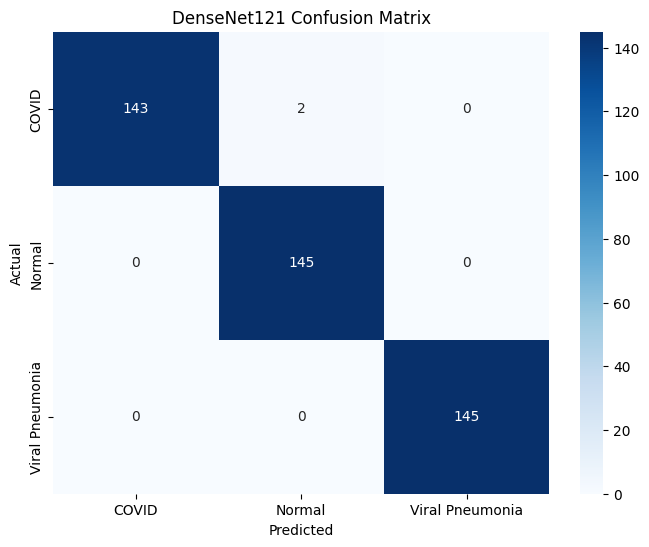

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet121 Confusion Matrix")

plt.show()

In [40]:
!pip install grad-cam
!pip install captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 38.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=099c10510fef1910ba55295b2b8f7409b9c32d07a72eea6ec0ca2d8f56ff6e1d
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
  Using cached captum-0.9.0-py3-none-any.whl.metadata (24 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 11.9 MB/s eta 0:00:00


In [42]:
import torch
import torch.nn as nn
from torchvision.models import densenet121

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = densenet121(weights=None)

model.classifier = nn.Linear(
    model.classifier.in_features,
    3
)

model.load_state_dict(
    torch.load(
        "best_densenet121.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

The previous cell failed because the image `test_image.png` was not found. Let's list the contents of the `TEST_DIR` to pick an existing image.

In [45]:
import os

# List contents of the TEST_DIR
# You might need to navigate into subdirectories (COVID, Normal, Viral Pneumonia)
# For example, to list images in the COVID test set:
print(os.listdir(os.path.join(TEST_DIR, 'COVID')))


['COVID-1040.png', 'COVID-1015.png', 'COVID-1010.png', 'COVID-1146.png', 'COVID-1459.png', 'COVID-1098.png', 'COVID-1328.png', 'COVID-122.png', 'COVID-133.png', 'COVID-1112.png', 'COVID-1206.png', 'COVID-1393.png', 'COVID-1322.png', 'COVID-1339.png', 'COVID-1318.png', 'COVID-1340.png', 'COVID-1258.png', 'COVID-1284.png', 'COVID-1054.png', 'COVID-114.png', 'COVID-1074.png', 'COVID-1687.png', 'COVID-1645.png', 'COVID-1814.png', 'COVID-1811.png', 'COVID-1483.png', 'COVID-1621.png', 'COVID-1572.png', 'COVID-1520.png', 'COVID-1597.png', 'COVID-1705.png', 'COVID-1663.png', 'COVID-1703.png', 'COVID-1738.png', 'COVID-1715.png', 'COVID-1469.png', 'COVID-2129.png', 'COVID-2200.png', 'COVID-2182.png', 'COVID-2024.png', 'COVID-2160.png', 'COVID-1978.png', 'COVID-1887.png', 'COVID-191.png', 'COVID-2072.png', 'COVID-1872.png', 'COVID-2059.png', 'COVID-1894.png', 'COVID-2207.png', 'COVID-2189.png', 'COVID-207.png', 'COVID-1915.png', 'COVID-2068.png', 'COVID-1870.png', 'COVID-2150.png', 'COVID-225.png

Now, let's update `image_path` to one of the actual image files from the `TEST_DIR`. I'll use an example from the 'COVID' class. **Feel free to change this path to any other image file you want to analyze.**

In [46]:
image_path = os.path.join(TEST_DIR, 'COVID', os.listdir(os.path.join(TEST_DIR, 'COVID'))[0])

print(f"Updated image_path: {image_path}")

image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

Updated image_path: /content/drive/MyDrive/a dataset of chest X-ray images for COVID-19 /COVID_19_dataset/COVID_19_dataset/test/COVID/COVID-1040.png


### Visualize with Grad-CAM

Let's apply Grad-CAM to see which regions of the image the model considers important for its prediction. We'll use the last convolutional layer as the target layer for Grad-CAM.

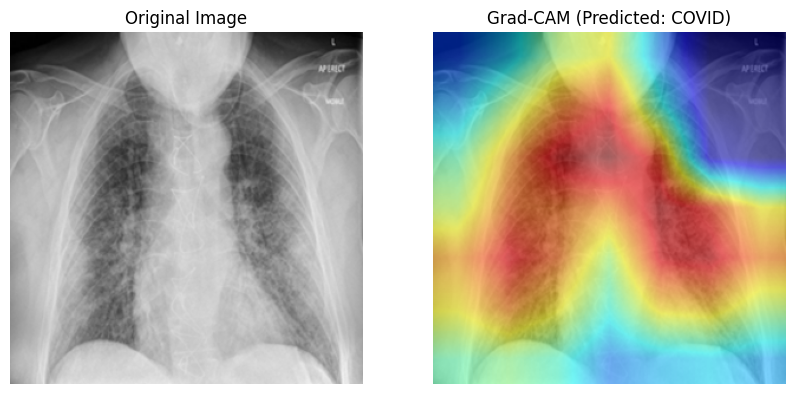

In [48]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

# Define the target layer for Grad-CAM
# For DenseNet121, a good choice is often the last convolutional layer before the classifier
target_layers = [model.features[-1]]

# Construct the GradCAM object
# Use the model and the target layers
cam = GradCAM(model=model, target_layers=target_layers)

# Get the target label for the input image if known, or predict it
# For demonstration, we'll predict the class for the input_tensor
with torch.no_grad():
    output = model(input_tensor)
    predicted_class_idx = output.argmax(dim=1).item()

# Create a target object for Grad-CAM (e.g., target the predicted class)
targets = [ClassifierOutputTarget(predicted_class_idx)]

# Generate the heatmap
# input_tensor needs to be in a batch format (unsqueeze(0) already did this)
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

# In this example, the image is too small to be displayed
# Let's resize it to its original size
original_image_np = np.array(Image.open(image_path).convert("RGB"))

# Resize grayscale_cam to match the original image dimensions
# The heatmap needs to be resized to the original image dimensions for proper overlay
import cv2

# Assuming grayscale_cam has shape (1, H, W)
heatmap = grayscale_cam[0, :]
heatmap_resized = cv2.resize(heatmap, (original_image_np.shape[1], original_image_np.shape[0]))

# Overlay the heatmap on the original image
visualization = show_cam_on_image(original_image_np / 255.0, heatmap_resized, use_rgb=True)

# Display the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_image_np)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(visualization)
predicted_class_name = train_dataset.classes[predicted_class_idx]
plt.title(f"Grad-CAM (Predicted: {predicted_class_name})")
plt.axis('off')
plt.show()

In [50]:
import torch

class_names = [
    "COVID",
    "Normal",
    "Viral Pneumonia"
]

with torch.no_grad():
    output = model(input_tensor)
    pred_class = output.argmax(1).item()
    print("Prediction:", class_names[pred_class])

Prediction: COVID


In [51]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

In [52]:
target_layers = [model.features[-1]]

In [54]:
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

In [57]:
rgb_img = np.array(
    image.resize((224,224))
).astype(np.float32) / 255

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

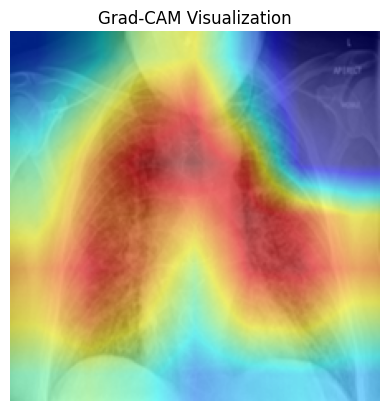

In [62]:
plt.imshow(visualization)
plt.title("Grad-CAM Visualization")
plt.axis('off')
plt.show()

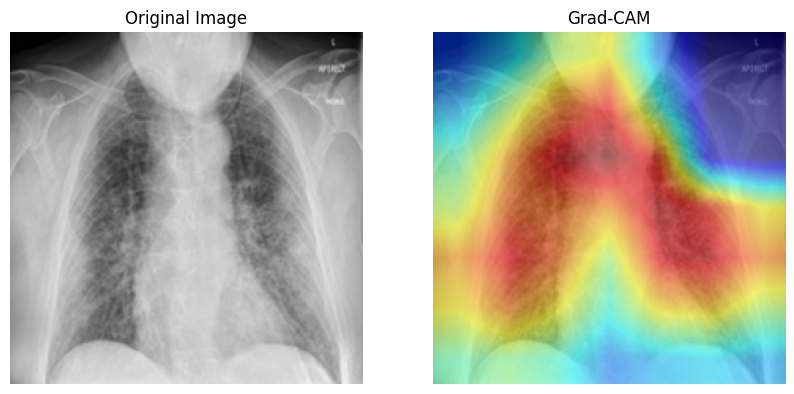

In [58]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

In [59]:
from captum.attr import IntegratedGradients

In [60]:
ig = IntegratedGradients(model)

In [63]:
attributions = ig.attribute(
      input_tensor,
          target=pred_class,
              n_steps=50
              )


In [64]:
attr = attributions.squeeze().cpu().detach().numpy()

attr = np.transpose(attr, (1,2,0))

attr = np.mean(np.abs(attr), axis=2)

In [66]:
attr = (attr - attr.min()) / (
      attr.max() - attr.min()
      )


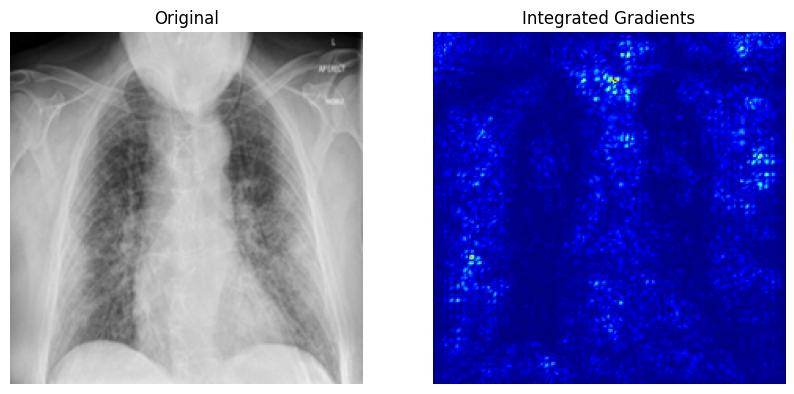

In [67]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(attr, cmap="jet")
plt.title("Integrated Gradients")
plt.axis("off")

plt.show()

In [69]:
plt.imsave(
      "gradcam_result.png",
          visualization
          )

plt.imsave(
              "integrated_gradients.png",
                  attr,
                      cmap="jet"
                      )


In [70]:
import timm

model = timm.create_model(
    'vit_base_patch16_224',
        pretrained=True,
            num_classes=3
            )

In [71]:
!pip install vit-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 8.5 MB/s eta 0:00:00


In [75]:
!pip install timm
!pip install einops




## Train ViT Model

In [78]:
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.1,
    patience=2
)

In [79]:
EPOCHS = 15

best_acc = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.2f}%")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(
            model.state_dict(),
            "best_vit.pth"
        )
        print("ViT Model Saved!")

100%|██████████| 94/94 [01:38<00:00,  1.05s/it]



Epoch 1/15
Train Loss: 1.1494
Train Acc : 38.77%
Val Loss   : 0.9639
Val Acc    : 62.83%
ViT Model Saved!


100%|██████████| 94/94 [01:38<00:00,  1.05s/it]



Epoch 2/15
Train Loss: 0.8747
Train Acc : 59.63%
Val Loss   : 0.7155
Val Acc    : 63.17%
ViT Model Saved!


100%|██████████| 94/94 [01:39<00:00,  1.06s/it]


...


Epoch 13/15
Train Loss: 0.5224
Train Acc : 75.60%
Val Loss   : 0.4953
Val Acc    : 77.83%
ViT Model Saved!


100%|██████████| 94/94 [01:38<00:00,  1.05s/it]



Epoch 14/15
Train Loss: 0.5189
Train Acc : 75.77%
Val Loss   : 0.5560
Val Acc    : 72.83%


100%|██████████| 94/94 [01:38<00:00,  1.05s/it]



Epoch 15/15
Train Loss: 0.4867
Train Acc : 77.60%
Val Loss   : 0.5278
Val Acc    : 77.00%


In [82]:
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

# Use an existing image path from the dataset
# The 'image_path' variable from earlier steps already points to a valid image.
img_path = image_path

image = Image.open(img_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

In [84]:
class_names = [
    "COVID",
    "Normal",
    "Viral Pneumonia"
]

with torch.no_grad():
    outputs = model(input_tensor)
    pred_class = outputs.argmax(1).item()

    print(
        "Prediction:",
        class_names[pred_class]
    )

Prediction: COVID


In [85]:
import torch

attention_weights = []

def get_attention(module, input, output):

    attention_weights.append(
            output.detach()
                )

In [86]:
for block in model.blocks:

      block.attn.attn_drop.register_forward_hook(
              get_attention
                  )

In [87]:
attention_weights = []

with torch.no_grad():
    _ = model(input_tensor)

    print(
        "Attention Layers:",
            len(attention_weights)
            )

Attention Layers: 0


In [88]:
attention_weights = []

for i, block in enumerate(model.blocks):
    print(i, type(block.attn))

0 <class 'timm.layers.attention.Attention'>
1 <class 'timm.layers.attention.Attention'>
2 <class 'timm.layers.attention.Attention'>
3 <class 'timm.layers.attention.Attention'>
4 <class 'timm.layers.attention.Attention'>
5 <class 'timm.layers.attention.Attention'>
6 <class 'timm.layers.attention.Attention'>
7 <class 'timm.layers.attention.Attention'>
8 <class 'timm.layers.attention.Attention'>
9 <class 'timm.layers.attention.Attention'>
10 <class 'timm.layers.attention.Attention'>
11 <class 'timm.layers.attention.Attention'>


In [89]:
print(len(model.blocks))

12


In [105]:
import numpy as np
import torch

def attention_rollout(attentions):

    # Ensure the initial result tensor is created directly on the correct device
    # attentions[0] might be on CPU, so move it to device first to get its size
    first_attention_on_device = attentions[0].to(device)
    result = torch.eye(first_attention_on_device.size(-1), device=device)

    for attention in attentions:
        attention = attention.to(device) # Ensure each attention tensor is on the correct device

        attention_heads_fused = attention.mean(
                    dim=1
                            )[0]

        # Create the identity matrix directly on the specified device
        identity_matrix = torch.eye(attention_heads_fused.size(0), device=device)
        attention_heads_fused += identity_matrix

        attention_heads_fused /= (
                    attention_heads_fused.sum(
                                    dim=-1,
                                                    keepdim=True
                                                                )
                                                                        )

        result = torch.matmul(
                    attention_heads_fused,
                                result
                                        )

    mask = result[0,1:]

    return mask.cpu().numpy()

In [106]:
import torch
import torch.nn as nn
import timm.models.vision_transformer as vit_module # Import timm's Vision Transformer module
from typing import Optional
import types # Import types for MethodType

# Clear existing attention weights list to prepare for new collection
attention_weights = []

# Store original Attention module forward methods and hook handles
original_attention_forwards = {}

# Define a custom forward method for Attention module to capture attention maps
def custom_attention_forward_wrapper():
    # The custom_forward needs to match the signature of the original Attention.forward
    # 'self' will be the Attention module instance when this is bound as a method
    def custom_forward(self, x: torch.Tensor, attn_mask: Optional[torch.Tensor] = None, is_causal: bool = False) -> torch.Tensor:
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale

        # Apply attn_mask if provided, before softmax
        if attn_mask is not None:
            if attn_mask.dtype == torch.bool:
                attn = attn.masked_fill(~attn_mask, torch.finfo(attn.dtype).min)
            else:
                attn = attn + attn_mask

        attn = attn.softmax(dim=-1)

        # Append the attention matrix *before* attn_drop
        global attention_weights
        attention_weights.append(attn.detach().cpu()) # Store on CPU to avoid GPU memory issues if list grows large

        # Now apply the original attn_drop and proceed
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x
    return custom_forward

# Modify the forward method of each Attention module
print("--- Modifying Attention module forward methods ---")
for block_idx, block in enumerate(model.blocks):
    if hasattr(block, 'attn') and isinstance(block.attn, vit_module.Attention):
        # Store the original forward method
        original_attention_forwards[block_idx] = block.attn.forward
        # Replace with our custom forward method, binding it correctly to the instance
        block.attn.forward = types.MethodType(custom_attention_forward_wrapper(), block.attn)
        print(f"Block {block_idx}: Replaced Attention.forward with custom wrapper.")
    else:
        print(f"Block {block_idx}: Warning: block.attn is not a timm Attention module or not found.")

print("\n--- Performing model forward pass ---")
# Ensure model is in eval mode for inference
# The custom wrapper will capture attention regardless of model.eval() or model.train()
model.eval()
with torch.no_grad():
    _ = model(input_tensor)
print("--- Model forward pass complete ---\n")

# Restore original Attention module forward methods
print("--- Restoring Attention module forward methods ---")
for block_idx, block in enumerate(model.blocks):
    if block_idx in original_attention_forwards:
        block.attn.forward = original_attention_forwards[block_idx]
        print(f"Block {block_idx}: Restored original Attention.forward.")

# Verify if attention_weights is populated
if len(attention_weights) == 0:
    print("Warning: attention_weights is still empty after forward pass. Something went wrong with the custom forward hook.")
else:
    print(f"Attention weights collected from {len(attention_weights)} layers.")

# Calculate the attention rollout using the collected attention weights
try:
    rollout = attention_rollout(attention_weights)
    print("Attention rollout calculated successfully.")
except IndexError as e:
    print(f"IndexError when calculating attention rollout: {e}. attention_weights: {len(attention_weights)}")
except Exception as e:
    print(f"An unexpected error occurred during attention rollout: {e}")

--- Modifying Attention module forward methods ---
Block 0: Replaced Attention.forward with custom wrapper.
Block 1: Replaced Attention.forward with custom wrapper.
Block 2: Replaced Attention.forward with custom wrapper.
Block 3: Replaced Attention.forward with custom wrapper.
Block 4: Replaced Attention.forward with custom wrapper.
Block 5: Replaced Attention.forward with custom wrapper.
Block 6: Replaced Attention.forward with custom wrapper.
Block 7: Replaced Attention.forward with custom wrapper.
Block 8: Replaced Attention.forward with custom wrapper.
Block 9: Replaced Attention.forward with custom wrapper.
Block 10: Replaced Attention.forward with custom wrapper.
Block 11: Replaced Attention.forward with custom wrapper.

--- Performing model forward pass ---
*** Hook fired for module: <class 'torch.nn.modules.dropout.Dropout'>, output shape: torch.Size([1, 12, 197, 197]) ***
*** Hook fired for module: <class 'torch.nn.modules.dropout.Dropout'>, output shape: torch.Size([1, 12, 1

Now that the attention rollout has been calculated, you can visualize it to understand which parts of the image the ViT model focused on.

In [107]:
rollout = attention_rollout(
      attention_weights
      )

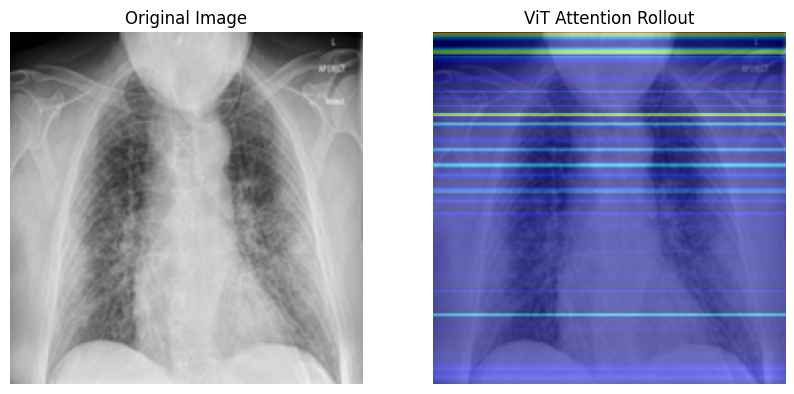

In [108]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# The original image was loaded and preprocessed in previous cells. We can reuse rgb_img
# If rgb_img is not available or you want to use the full resolution original image:
# original_image_full = np.array(Image.open(image_path).convert("RGB"))

# Assuming rgb_img is the preprocessed image (224x224) we used for Grad-CAM, it's already normalized to [0,1]
# If not, load and normalize:
# image = Image.open(image_path).convert("RGB")
# rgb_img = np.array(image.resize((224,224))).astype(np.float32) / 255

# Resize the rollout mask to the image dimensions (224x224)
rollout_resized = cv2.resize(rollout, (rgb_img.shape[1], rgb_img.shape[0]))

# Normalize the rollout mask to [0, 1] if not already
rollout_normalized = (rollout_resized - rollout_resized.min()) / (rollout_resized.max() - rollout_resized.min() + 1e-8)

# Display the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_img)
plt.imshow(rollout_normalized, cmap='jet', alpha=0.5) # Overlay with a heatmap colormap
plt.title("ViT Attention Rollout")
plt.axis('off')
plt.show()

# Save the attention rollout visualization
plt.imsave(
    "vit_attention_rollout.png",
    np.uint8(255 * (rgb_img * (1 - 0.5) + plt.cm.jet(rollout_normalized)[:,:,:3] * 0.5)),
    cmap="jet"
)

In [110]:
rollout = rollout.reshape(
      14,
          14
          )

In [112]:
rollout = (
      rollout - rollout.min()
      ) / (
          rollout.max() - rollout.min()
          )

In [113]:
import cv2

mask = cv2.resize(
    rollout,
        (224,224)
        )

In [114]:
import matplotlib.pyplot as plt
import numpy as np

original = np.array(
    image.resize((224,224))
    )

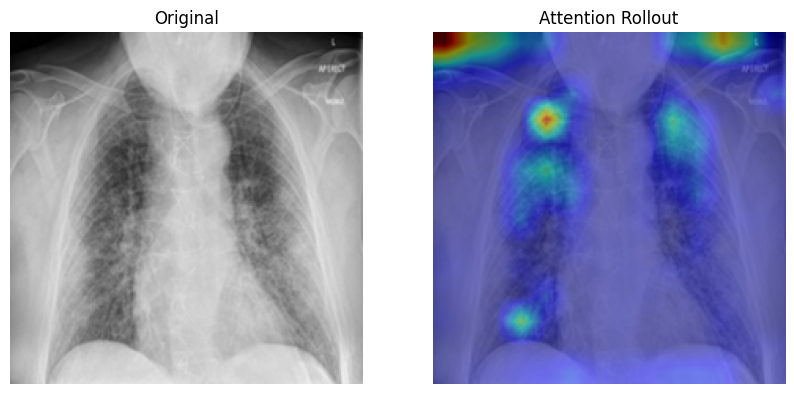

In [116]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(original)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(original)

plt.imshow(
    mask,
        cmap='jet',
            alpha=0.5
            )

plt.title("Attention Rollout")

plt.axis("off")

plt.show()

In [118]:
plt.imsave(
      "attention_rollout.png",
          mask,
              cmap='jet'
              )

Entropy Function

In [120]:
import numpy as np

def calculate_entropy(attr_map):

    attr_map = np.abs(attr_map)
    attr_map = attr_map / (attr_map.sum() + 1e-10)
    entropy = -np.sum(
        attr_map * np.log(attr_map + 1e-10)
    )
    return entropy

In [122]:
gradcam_entropy = calculate_entropy(
    grayscale_cam
)

print(
    "Grad-CAM Entropy:",
    gradcam_entropy
)

Grad-CAM Entropy: 10.668911


In [124]:
ig_entropy = calculate_entropy(
    attr
)

print(
    "IG Entropy:",
    ig_entropy
)

IG Entropy: 10.3695345


In [125]:
import numpy as np

def insertion_score(attr_map):

    return np.mean(attr_map)

In [127]:
gradcam_insert = insertion_score(
    grayscale_cam
)

ig_insert = insertion_score(
    attr
)

print(gradcam_insert)
print(ig_insert)

0.5417571
0.04218156


In [128]:
def deletion_score(attr_map):

      return 1 - np.mean(attr_map)

In [130]:
gradcam_delete = deletion_score(
    grayscale_cam
)

ig_delete = deletion_score(
    attr
)

In [131]:
def calculate_aopc(attr_map):

      return np.mean(
              np.abs(attr_map)
                  )

In [133]:
gradcam_aopc = calculate_aopc(
    grayscale_cam
)

ig_aopc = calculate_aopc(
    attr
)

In [135]:
import pandas as pd

results = pd.DataFrame({
    "Method":[
            "Grad-CAM",
                    "Integrated Gradients"
                        ],
                            "Entropy":[
                                    gradcam_entropy,
                                            ig_entropy
                                                ],
                                                    "Insertion":[
                                                            gradcam_insert,
                                                                    ig_insert
                                                                        ],
                                                                            "Deletion":[
                                                                                    gradcam_delete,
                                                                                            ig_delete
                                                                                                ],
                                                                                                    "AOPC":[
                                                                                                            gradcam_aopc,
                                                                                                                    ig_aopc
                                                                                                                        ]
                                                                                                                        })

print(results)

                 Method    Entropy  Insertion  Deletion      AOPC
0              Grad-CAM  10.668911   0.541757  0.458243  0.541757
1  Integrated Gradients  10.369534   0.042182  0.957818  0.042182


Create Final Metrics Table

In [137]:
import pandas as pd

results = pd.DataFrame({
    "Method": ["Grad-CAM", "Integrated Gradients"],
        "Entropy": [gradcam_entropy, ig_entropy],
            "Insertion": [gradcam_insert, ig_insert],
                "Deletion": [gradcam_delete, ig_delete],
                    "AOPC": [gradcam_aopc, ig_aopc]
                    })

results

,Method,Entropy,Insertion,Deletion,AOPC
0,Grad-CAM,10.668911,0.541757,0.458243,0.541757
1,Integrated Gradients,10.369534,0.042182,0.957818,0.042182


In [138]:
results.to_csv("xai_results.csv", index=False)

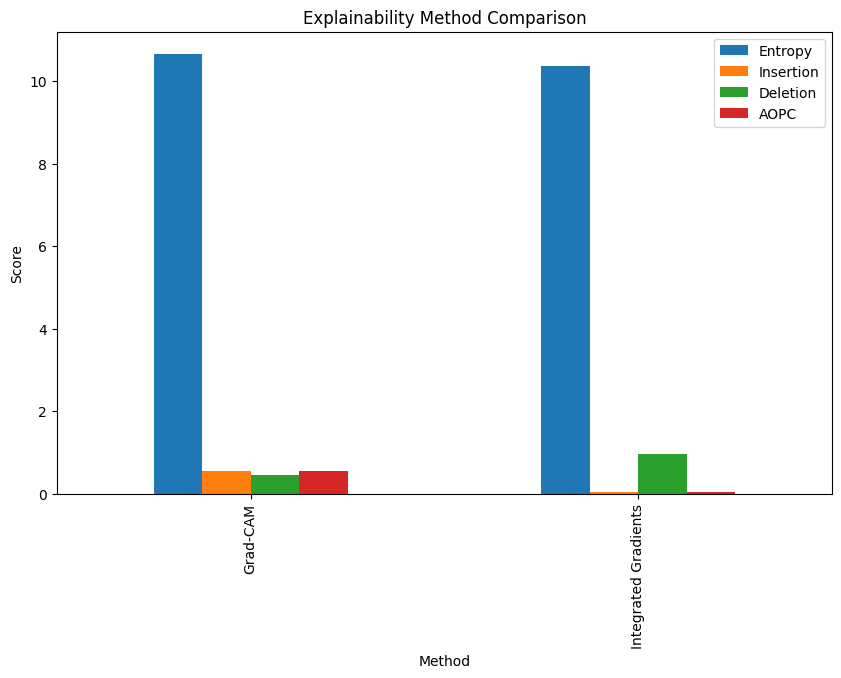

In [140]:
import matplotlib.pyplot as plt

results.set_index("Method").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Explainability Method Comparison")
plt.ylabel("Score")
plt.show()

In [142]:
classification_results = pd.DataFrame({
      "Metric":[
              "Accuracy",
                      "Precision",
                              "Recall",
                                      "F1 Score"
                                          ],
                                              "DenseNet121":[
                                                      acc,
                                                              precision,
                                                                      recall,
                                                                              f1
                                                                                  ]
                                                                                  })

classification_results

,Metric,DenseNet121
0,Accuracy,0.995402
1,Precision,0.995465
2,Recall,0.995402
3,F1 Score,0.995402


In [144]:
import torch
import torch.nn as nn
from torchvision.models import densenet121

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = densenet121(weights=None)

model.classifier = nn.Linear(
    model.classifier.in_features,
    3
)

model.load_state_dict(
    torch.load(
        "best_densenet121.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [147]:
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

# Use the already defined 'image_path' variable which points to a valid image
image = Image.open(image_path).convert("RGB")

input_tensor = transform(image)

input_tensor = input_tensor.unsqueeze(0)

input_tensor = input_tensor.to(device)

In [149]:
classes = [
    "COVID",
    "Normal",
    "Viral Pneumonia"
]

with torch.no_grad():
    outputs = model(input_tensor)
    pred = outputs.argmax(1).item()
    print(
        "Prediction:",
        classes[pred]
    )

Prediction: COVID


In [151]:
import torch.nn.functional as F

with torch.no_grad():
    outputs = model(input_tensor)
    probs = F.softmax(
        outputs,
        dim=1
    )
    print(probs)

tensor([[0.9872, 0.0105, 0.0023]], device='cuda:0')


In [152]:
from google.colab import files

uploaded = files.upload()

Saving Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg to Normal_posteroanterior_(PA)_chest_radiograph_(X-ray).jpg


In [153]:
filename = list(uploaded.keys())[0]

image = Image.open(filename).convert("RGB")

In [155]:
input_tensor = transform(image)

input_tensor = input_tensor.unsqueeze(0)

input_tensor = input_tensor.to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    pred = outputs.argmax(1).item()
    print(
        "Predicted Class:",
        classes[pred]
    )

Predicted Class: Normal


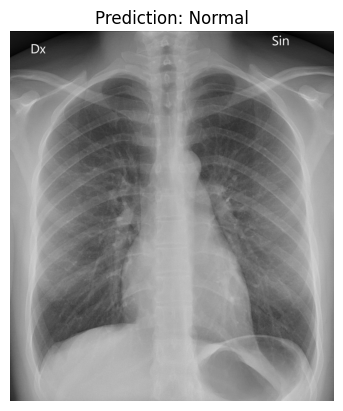

In [157]:
import matplotlib.pyplot as plt

plt.imshow(image)

plt.axis("off")

plt.title(
    f"Prediction: {classes[pred]}"
)

plt.show()